In [10]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u

In [11]:
#zuleta functions
'''
def _vkep(p0, phi, mstar, dist):
            r_vals = np.hypot(p0[:, :, 0], p0[:, :, 1])
            z_vals = p0[:, :, 2]
            
            #my addition
            G = const.g.value
            msun = const.m_sun.value

            #r_m = r_vals * sc.au * dist
            #z_m = z_vals * sc.au * dist
            
            vkep = G * mstar * self.msun * np.power(r_m, 2)
            v = np.sqrt(vkep * np.power(np.hypot(r_m, z_m), -3))
            v = v  * np.array([-np.sin(phi), np.cos(phi), np.zeros_like(phi)])
            return np.moveaxis(v, 0, 2)
'''

def warp_transformation(x, y, z, theta, phi):
    xprime =  x*np.cos(phi) - y*np.sin(phi)*np.cos(theta) + z*np.sin(phi)*np.sin(theta)
    yprime = x*np.sin(phi) + y*np.cos(phi)*np.cos(theta) - z*np.sin(theta)*np.cos(phi)
    zprime = y*np.sin(theta) + z*np.cos(theta)
    return xprime, yprime, zprime

def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

def w_func(a, r0, dr, r):
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
    #    a = self.w_i

    #elif type == "pa":
    #    a = self.pa

    #print("a " + str(a))
    #print("r0 " + str(r0))
    #print("dr " + str(dr))
    #print("r max" + str(np.max(r)))
    #print("r min" + str(np.min(r)))
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr
    return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))


In [27]:
warp_inc = 20 #degrees
twist_angle = 0 #degrees
r0 = 20 #au
dr = 1 #au
rotation = 90 #degrees
inclination = 50 #degrees

/tmp/ipykernel_89485/2347719778.py:22: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(XC[:,:,25], YC[:,:,25], ZC[:,:,25])


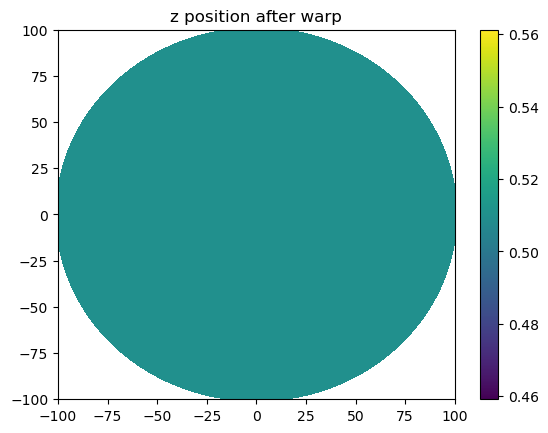

/tmp/ipykernel_89485/2347719778.py:29: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(XC[:,:,25], YC[:,:,25], vy[:,:,25], cmap='RdBu_r')


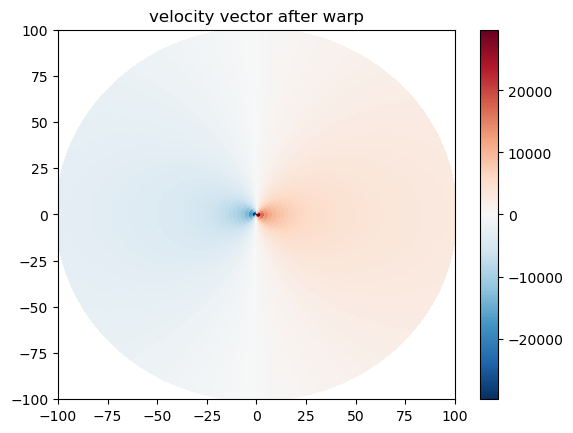

In [28]:
# Make the full mesh
rc = np.linspace(1, 100, 50)
thetac = np.linspace(0, 2*np.pi, 300)
zc = np.linspace(-25, 25, 50)
RC, THETAC, ZC = np.meshgrid(rc, thetac, zc, indexing='ij')

XC, YC = pol2cart(RC, THETAC)

#RU_au = np.sqrt(XC**2 + YC**2 + ZC**2)*u.au
RU_au = np.sqrt(XC**2 + YC**2)*u.au
RU = RU_au.to(u.m)
VPU = np.sqrt(const.G * const.M_sun / RU)
VPU[:,:,0]
#ZC = zc

vx = -VPU*np.sin(THETAC)
vy = VPU*np.cos(THETAC)
vz = np.zeros(THETAC.shape)



plt.pcolor(XC[:,:,25], YC[:,:,25], ZC[:,:,25])
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("z position after warp")
plt.colorbar()
plt.show()

plt.pcolor(XC[:,:,25], YC[:,:,25], vy[:,:,25], cmap='RdBu_r')
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("velocity vector after warp")
plt.colorbar()
plt.show()

/tmp/ipykernel_89485/3197485653.py:54: RuntimeWarning: overflow encountered in exp
  return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr))))
/tmp/ipykernel_89485/1426866333.py:9: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(xw[:,:,25], yw[:,:,25], zw[:,:,25])


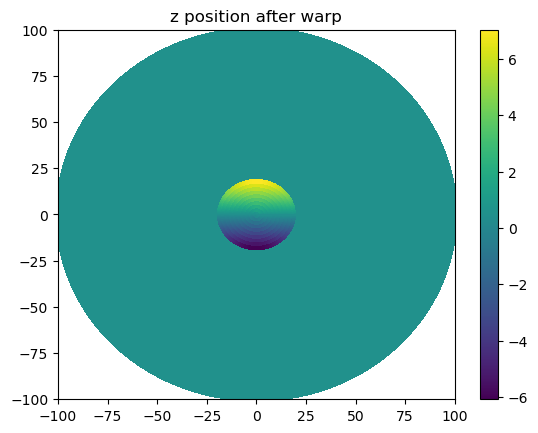

/tmp/ipykernel_89485/1426866333.py:16: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(xw[:,:,25], yw[:,:,25], vwy[:,:,25], cmap='RdBu_r')


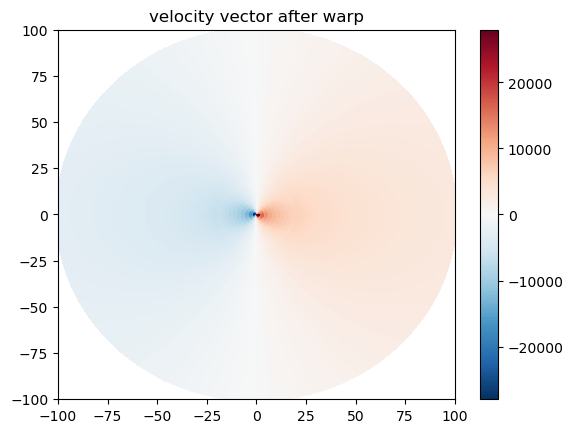

In [29]:
#warping the disk
twist = w_func(twist_angle, r0, dr, rc)[:, None, None]
warp = w_func(warp_inc, r0, dr, rc)[:, None, None]

#vwx, vwy, vwz = warp_transformation(vx, vy, vz, warp, np.zeros(len(twist)))
vwx, vwy, vwz = warp_transformation(vx, vy, vz, warp, twist)
xw, yw, zw = warp_transformation(XC, YC, ZC, warp, twist)

plt.pcolor(xw[:,:,25], yw[:,:,25], zw[:,:,25])
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("z position after warp")
plt.colorbar()
plt.show()

plt.pcolor(xw[:,:,25], yw[:,:,25], vwy[:,:,25], cmap='RdBu_r')
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("velocity vector after warp")
plt.colorbar()
plt.show()


/tmp/ipykernel_89485/2628141180.py:9: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(trotx[:,:,25], troty[:,:,25], zw[:,:,25])


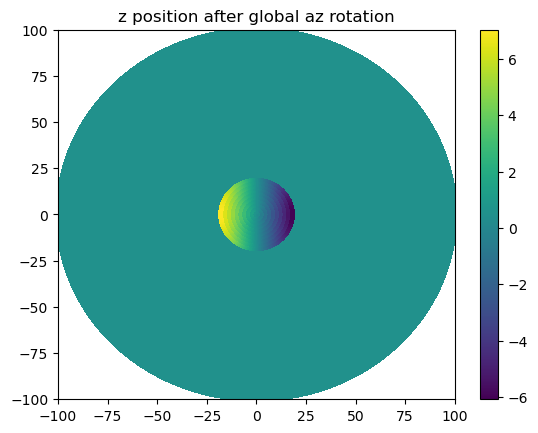

/tmp/ipykernel_89485/2628141180.py:16: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(trotx[:,:,25], troty[:,:,25], vwz[:,:,25], cmap='RdBu_r')


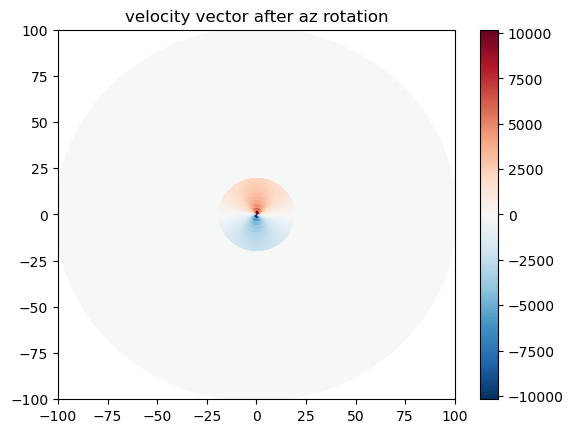

In [30]:
#now, global az rotation of the disk:
rot = np.radians(rotation)
trotx = xw*np.cos(rot)-yw*np.sin(rot) 
troty = xw*np.sin(rot)+yw*np.cos(rot) 
 
rotvx = vwx*np.cos(rot)-vwy*np.sin(rot) 
rotvy = vwx*np.sin(rot)+vwy*np.cos(rot) 

plt.pcolor(trotx[:,:,25], troty[:,:,25], zw[:,:,25])
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("z position after global az rotation")
plt.colorbar()
plt.show()

plt.pcolor(trotx[:,:,25], troty[:,:,25], vwz[:,:,25], cmap='RdBu_r')
plt.xlim(-100, 100)
plt.ylim(-100,100)
plt.title("velocity vector after az rotation")
plt.colorbar()
plt.show()

/tmp/ipykernel_89485/221553895.py:19: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tdiskZ_rot[:,:,25])


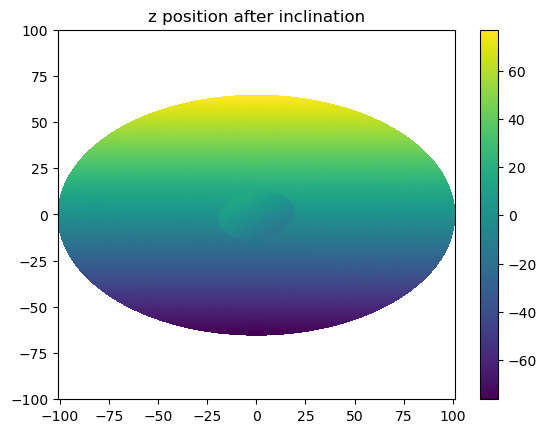

/tmp/ipykernel_89485/221553895.py:26: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tvz_rot[:,:,25], cmap='RdBu_r')


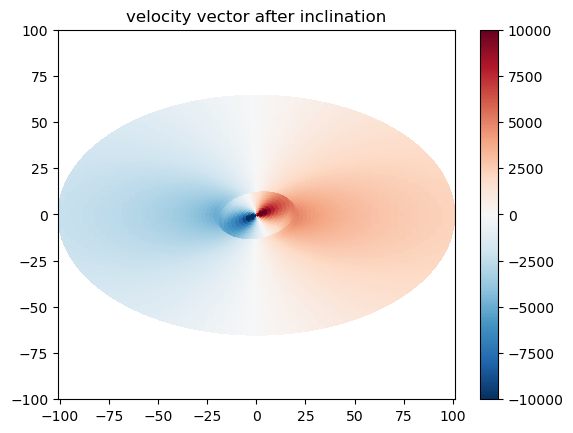

'\nplt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tvz[:,:,25], cmap=\'RdBu_r\')\n#plt.pcolor(xw[:,:,0], tdiskY[:,:,0], tvz[:,:,0])\nplt.title("velocity vector after inclination without az vel rotation")\nplt.ylim(-100, 100)\nplt.clim(-10000, 10000)\nplt.colorbar()\nplt.show()\n'

In [31]:
#now, inclining the disk:
inc = np.radians(inclination)

tdiskY = (yw*np.cos(inc) - zw*np.sin(inc)) 
tdiskZ = (yw*np.sin(inc) + zw*np.cos(inc))# 
 
tvy = (vwy*np.cos(inc) - vwz*np.sin(inc)) 
tvz = (vwy*np.sin(inc) + vwz*np.cos(inc)) 
 
#with rotation: 
tdiskY_rot = (troty*np.cos(inc) - zw*np.sin(inc)) 
tdiskZ_rot = (troty*np.sin(inc) + zw*np.cos(inc)) 


 
tvy_rot = (rotvy*np.cos(inc) - vwz*np.sin(inc)) 
tvz_rot = (rotvy*np.sin(inc) + vwz*np.cos(inc)) 

plt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tdiskZ_rot[:,:,25])
#plt.pcolor(xw[:,:,0], tdiskY[:,:,0], tvz[:,:,0])
plt.title("z position after inclination")
plt.ylim(-100, 100)
plt.colorbar()
plt.show()

plt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tvz_rot[:,:,25], cmap='RdBu_r')
#plt.pcolor(xw[:,:,0], tdiskY[:,:,0], tvz[:,:,0])
plt.title("velocity vector after inclination")
plt.ylim(-100, 100)
plt.clim(-10000, 10000)
plt.colorbar()
plt.show()
'''
plt.pcolor(trotx[:,:,25], tdiskY_rot[:,:,25], tvz[:,:,25], cmap='RdBu_r')
#plt.pcolor(xw[:,:,0], tdiskY[:,:,0], tvz[:,:,0])
plt.title("velocity vector after inclination without az vel rotation")
plt.ylim(-100, 100)
plt.clim(-10000, 10000)
plt.colorbar()
plt.show()
'''

